In [ ]:
# Таблица 1
# company_id - идентификатор кампании
# company_type - тип объявлений в кампании (графическая, текст, видео)
# cost - затраты на кампанию

# Таблица 2
# company_id
# datetime - день, в который пользователь просмотрел объявление
# client_id - пользователь
# buy - 1 или 0 (пользователь совершил покупку, либо нет)

# P.S Доход с покупки 300, затраты на 1 просмотр

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import os

data_1 = pd.read_excel('/content/team3_data.xlsx')
data_2 = pd.read_excel('/content/team3_data.xlsx', sheet_name='Таблица 2')
data_1.head()

,company_id,company_type,cost
0,1,графическая,58
1,2,текст,10
2,3,видео,77
3,4,графическая,45


In [ ]:
data_2.head()

,company_id,datetime,client_id,buy
0,1,2021-01-02,1,0
1,1,2021-01-04,2,1
2,1,2021-01-01,3,0
3,1,2021-01-05,4,0
4,1,2021-01-03,5,0


In [ ]:
data3 = data_2.merge(data_1, on='company_id', how = 'left')
#first_pupil_df.merge(second_pupil_df, on='author', how='left')
data3.head()

,company_id,datetime,client_id,buy,company_type,cost
0,1,2021-01-02,1,0,графическая,58
1,1,2021-01-04,2,1,графическая,58
2,1,2021-01-01,3,0,графическая,58
3,1,2021-01-05,4,0,графическая,58
4,1,2021-01-03,5,0,графическая,58


Проверка данных

In [ ]:
#Проверка на пропуски в данных
data3.info()
#Количество строк  - 4000
#в каждом столбце 4000 значений, значит пропусков нет

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   company_id    4000 non-null   int64         
 1   datetime      4000 non-null   datetime64[ns]
 2   client_id     4000 non-null   int64         
 3   buy           4000 non-null   int64         
 4   company_type  4000 non-null   object        
 5   cost          4000 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 218.8+ KB


In [ ]:
#Проверка на дубликаты в client_id
data3['client_id'].value_counts().sort_values(ascending=False)
#все уникальные

1       1
14      1
31      1
30      1
3       1
       ..
3995    1
3996    1
3997    1
3998    1
4000    1
Name: client_id, Length: 4000, dtype: int64

Анализ данных

In [ ]:
#Конверсия CR
print(data3.groupby('company_id')['company_id'].count())
#У каждой компании по 1000 наблюдений
data3.groupby('company_id')['buy'].sum()
print('......')
#Количество целевых действий
#Конверсия в %
conversion=data3.groupby('company_id')['buy'].sum()/1000*100
print(conversion)

company_id
1    1000
2    1000
3    1000
4    1000
Name: company_id, dtype: int64
......
company_id
1    38.4
2    13.1
3    51.8
4    44.9
Name: buy, dtype: float64


In [ ]:
#CPO - Расходы на рекламу
df1=data3.groupby('company_id')['cost'].sum()
df2=data3.groupby('company_id')['buy'].sum()
df3 = pd.concat([df1, df2], axis=1)
df3['revenue']=df3['buy']*300
df3['CPO']=round(df3['cost']/df3['buy'], 2)

#ROAS -  Рентабельность затрат на рекламу
#ROAS = (Доход с рекламы / Расходы на рекламу) * 100%
df3['ROI']=round((df3['buy']*300-df3['cost'])/df3['cost']*100, 2)
df3['CPC']=round(df3['cost']/1000, 2)
df3['CR'] = conversion
print(df3)

             cost  buy  revenue     CPO     ROI   CPC    CR
company_id                                                 
1           58000  384   115200  151.04   98.62  58.0  38.4
2           10000  131    39300   76.34  293.00  10.0  13.1
3           77000  518   155400  148.65  101.82  77.0  51.8
4           45000  449   134700  100.22  199.33  45.0  44.9


Визуализации. Часть 1

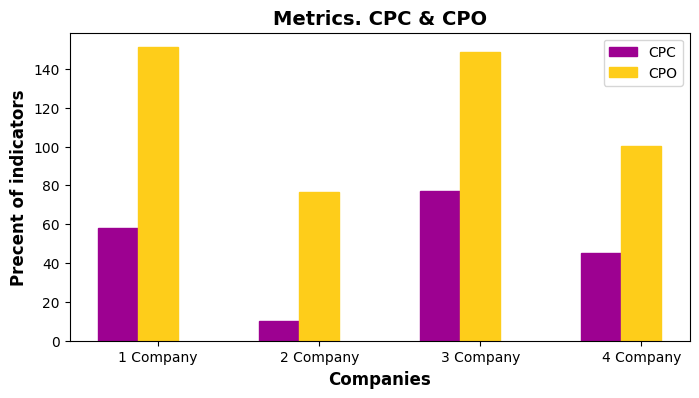

In [ ]:
# ROE и CPO

#создаем список названий кампаний
x = []
for i in data3['company_id'].unique():
  x.append(f'{i} Company')
barWidth = 0.25
fig = plt.subplots(figsize =(8, 4))

CPC = list(df3['CPC'])
CPO = list(df3['CPO'])

br1 = np.arange(len(CPC))
br2 = [x + barWidth for x in br1]

plt.bar(br1, CPC, color ='#9D0191', width = barWidth,
        edgecolor ='#9D0191', label ='CPC')
plt.bar(br2, CPO, color ='#FECD1A', width = barWidth,
        edgecolor ='#FECD1A', label ='CPO')

plt.xlabel('Companies', fontweight ='bold', fontsize = 12, color = "black")
plt.ylabel('Precent of indicators', fontweight ='bold', fontsize = 12, color = "black")
plt.xticks([r + barWidth for r in range(len(CPC))],x, color = "black")

plt.title('Metrics. CPC & CPO', fontweight ='bold', fontsize = 14,color = "black")
#аннотировать данные ещё

plt.legend()
plt.show()

Text(0.55, 1.18, 'Calculated by company')

<Figure size 800x500 with 0 Axes>

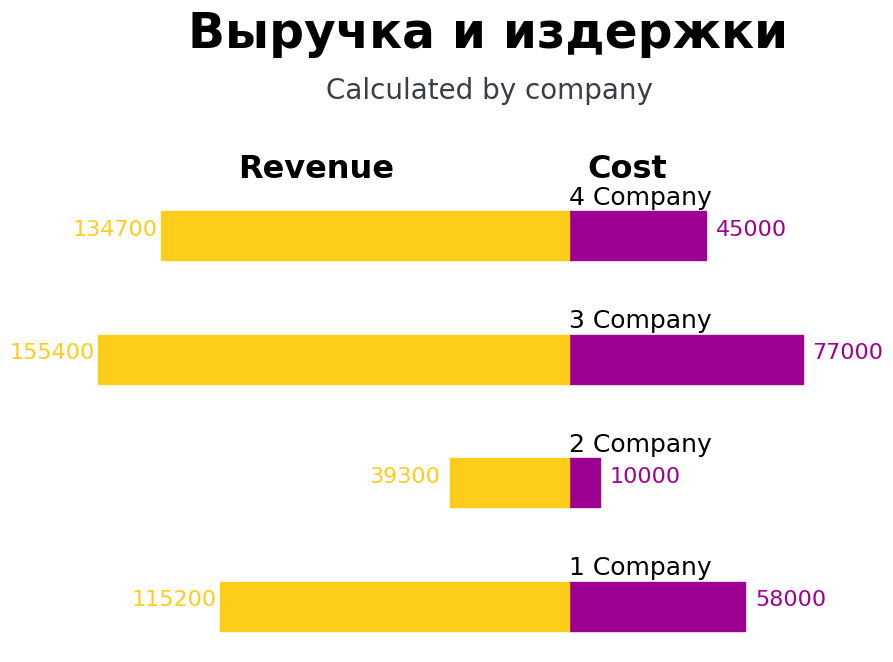

In [ ]:
fig = plt.figure(figsize=(8, 5), facecolor='#FFFFFF')
dfrevenue = df3.revenue
dfcost = df3.cost
companies = data_1['company_id']

catPos = np.arange(len(companies))


fig, ax = plt.subplots(figsize=(10,6), facecolor='#FFFFFF')
ax.barh(companies + 0.1, dfcost, align='center', height = 0.4,facecolor='#9D0191',edgecolor='#9D0191')
ax.barh(companies + 0.1, dfrevenue*-1, align='center', height = 0.4,facecolor='#FECD1A',edgecolor='#FECD1A')

for i, cost in enumerate(dfcost):
    ax.text(cost + 15000, companies[i] + 0.1, cost, ha='center', size = 16,color = "#9D0191")
for i, revenue in enumerate(dfrevenue):
    ax.text((revenue*-1) -15000, companies[i] + 0.1, revenue, ha='center', size = 16,color = "#FECD1A")
for  bar, cat in zip(ax.patches, x):
    width = bar.get_width()
    label_y = bar.get_y() + bar.get_height() +0.05
    plt.text(0, label_y, s=f'{cat}', size = 18, color = '#000000')

plt.figtext(0.30, 0.90, 'Revenue', fontsize=23, rotation=0, weight="bold", color = '#000000')
plt.figtext(0.65, 0.90, 'Cost', fontsize=23, rotation=0, weight="bold", color = '#000000')

plt.box(False)
plt.axis('off')

plt.suptitle('Выручка и издержки',  fontsize = 35, x=0.55, y=1.18 ,weight="bold",color = '#000000')
plt.title("Calculated by company", fontsize = 20, x=0.55, y=1.18, color = "#393E46")


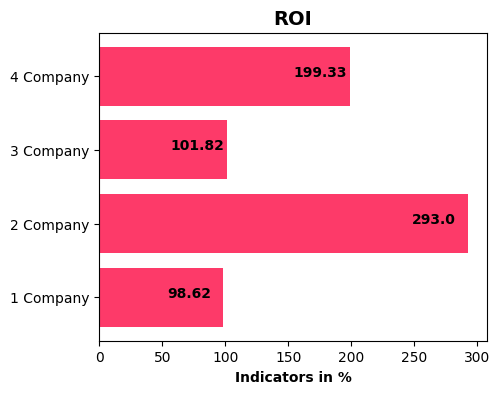

In [ ]:
#ROI
ROI = list(df3['ROI'])
plt.figure(figsize=(5, 4), facecolor='#FFFFFF')

plt.barh(x, ROI, color = "#FD3A69")

for index, value in enumerate(ROI):
    plt.text(value - 45, index,
             str(value), color = 'black',fontweight ='bold')

plt.xlabel("Indicators in %", color = "#000000", fontweight ='bold')
plt.title('ROI', fontweight ='bold', fontsize = 14, color = "#000000")
plt.show()

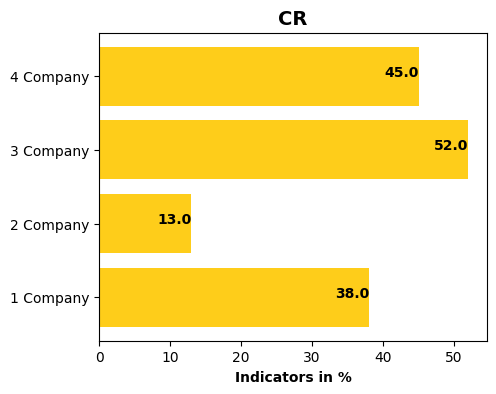

In [ ]:
#CR
CR = list(round(df3['CR']))
plt.figure(figsize=(5, 4), facecolor='#FFFFFF')

plt.barh(x, CR, color = "#FECD1A")

for index, value in enumerate(CR):
    plt.text(value, index,
             str(value), ha='right', color='black',fontweight ='bold')

plt.xlabel("Indicators in %", color = "black", fontweight ='bold')
plt.title('CR', fontweight ='bold', fontsize = 14, color = "black")
plt.show()

Анализ временных данных

In [ ]:
time = sorted(list(data3['datetime'].unique()))
time

[numpy.datetime64('2021-01-01T00:00:00.000000000'),
 numpy.datetime64('2021-01-02T00:00:00.000000000'),
 numpy.datetime64('2021-01-03T00:00:00.000000000'),
 numpy.datetime64('2021-01-04T00:00:00.000000000'),
 numpy.datetime64('2021-01-05T00:00:00.000000000'),
 numpy.datetime64('2021-01-06T00:00:00.000000000'),
 numpy.datetime64('2021-01-07T00:00:00.000000000'),
 numpy.datetime64('2021-01-08T00:00:00.000000000')]

In [ ]:
#просмотры (визиты) по дням
visit = data3.groupby('datetime')['client_id'].count()
print(visit)
print('........')
#количество покупок по дня
buy = data3.groupby('datetime')['buy'].sum()
print(buy)
visit = list(visit)
buy = list(buy)

datetime
2021-01-01    502
2021-01-02    533
2021-01-03    488
2021-01-04    528
2021-01-05    497
2021-01-06    512
2021-01-07    472
2021-01-08    468
Name: client_id, dtype: int64
........
datetime
2021-01-01    194
2021-01-02    202
2021-01-03    171
2021-01-04    193
2021-01-05    180
2021-01-06    198
2021-01-07    172
2021-01-08    172
Name: buy, dtype: int64


In [ ]:
#подневная конверция
print(data3.groupby('datetime')['buy'].sum()) #покупки по дням
print('............')
print(data3.groupby('datetime')['client_id'].count()) #визиты по дням
cr = list((data3.groupby('datetime')['buy'].sum() / data3.groupby('datetime')['client_id'].count() )*100)


datetime
2021-01-01    194
2021-01-02    202
2021-01-03    171
2021-01-04    193
2021-01-05    180
2021-01-06    198
2021-01-07    172
2021-01-08    172
Name: buy, dtype: int64
............
datetime
2021-01-01    502
2021-01-02    533
2021-01-03    488
2021-01-04    528
2021-01-05    497
2021-01-06    512
2021-01-07    472
2021-01-08    468
Name: client_id, dtype: int64


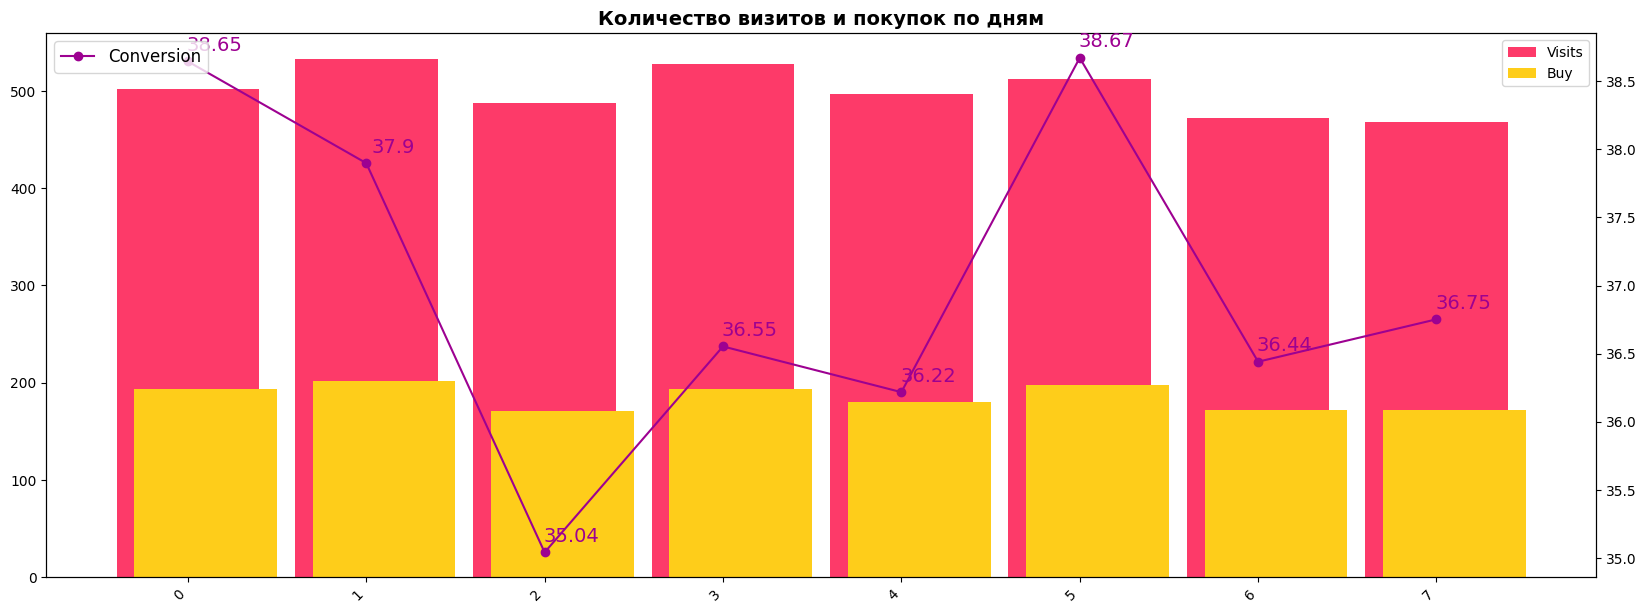

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(20, 8))

barWidth = 0.1
br1 = np.arange(len(visit))
br2 = [x + barWidth for x in br1]
ax.bar(br1, visit, color='#FD3A69', label='Visits')
ax.bar(br2, buy, color='#FECD1A', label='Buy')

ax2 = ax.twinx()
line = ax2.plot(cr, color='#9D0191',linestyle = '-', marker='o', label = 'Conversion')

for i, val in enumerate(cr):
    ax2.text(i+0.15, val+0.05, f'{round(val,2)}', ha='center', va='bottom', fontsize=14, color='#9D0191')

#ax.set_xticks([r + barWidth for r in range(len(time))])
#ax.set_xticklabels()

plt.title('Количество визитов и покупок по дням', fontweight ='bold', fontsize = 14,color = "black")

fig.autofmt_xdate(rotation=45)
ax.legend()
ax2.legend(loc = 'upper left', fontsize = 12)

Визуализация. Часть 3

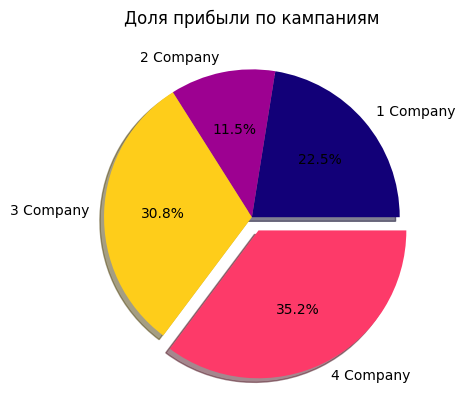

In [ ]:
#доля компаний по прибыли на круговой
pi = df3['revenue']-df3['cost']
exploding = [0, 0, 0, 0.1]


fig1, ax1 = plt.subplots()
ax1.pie(pi, labels=x, autopct='%1.1f%%',
        colors=['#120078','#9D0191', '#FECD1A','#FD3A69'],
        shadow = True,
        explode=exploding)
ax1.set_title('Доля прибыли по кампаниям', color='black')
plt.show()

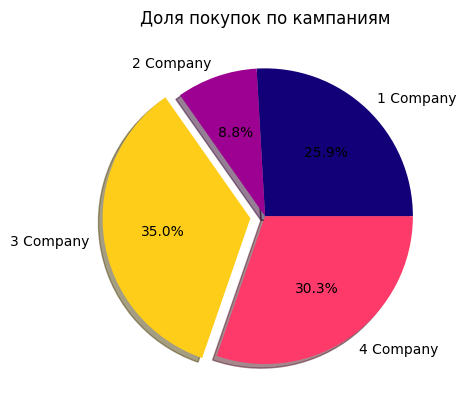

In [ ]:
#доля компаний по покупкам на круговой
exploding = [0, 0, 0.1, 0]

bues = data3.groupby('company_id')['buy'].sum()

fig1, ax1 = plt.subplots()
ax1.pie(bues, labels=x, autopct='%1.1f%%',
        colors=['#120078','#9D0191', '#FECD1A','#FD3A69'],
        shadow = True,
        explode=exploding)

ax1.set_title('Доля покупок по кампаниям')
plt.show()

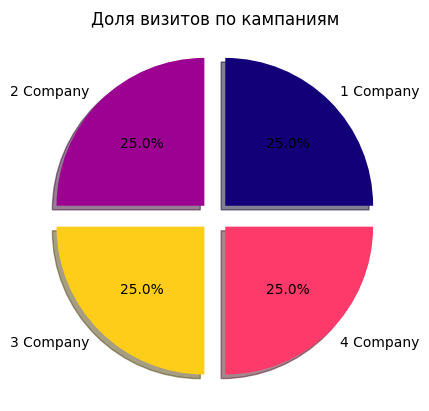

In [ ]:
#визиты
exploding = [0.1, 0.1, 0.1, 0.1]

clients = data3.groupby('company_id')['company_id'].count()

fig1, ax1 = plt.subplots()
ax1.pie(clients, labels=x, autopct='%1.1f%%',
        colors= ['#120078','#9D0191', '#FECD1A','#FD3A69'],
        shadow = True,
        explode=exploding)

ax1.set_title('Доля визитов по кампаниям')
plt.show()

In [ ]:
buy_c = data3.groupby(['datetime', 'company_id'])['buy'].sum().reset_index()
print(buy_c)

visit_buy_c = pd.concat([visit_c, buy_c['buy']], axis=1)
visit_buy_c['CR'] = round(visit_buy_c['buy']/visit_buy_c['client_id']*100, 2)
print(visit_buy_c)
visit_buy_c1 = visit_buy_c[visit_buy_c['company_id']==1]
visit_buy_c2 = visit_buy_c[visit_buy_c['company_id']==2]
visit_buy_c3 = visit_buy_c[visit_buy_c['company_id']==3]
visit_buy_c4 = visit_buy_c[visit_buy_c['company_id']==4]
print(visit_buy_c1)

In [ ]:
cr_1 = visit_buy_c[visit_buy_c['company_id']==1]
cr_2 = visit_buy_c[visit_buy_c['company_id']==2]
cr_3 = visit_buy_c[visit_buy_c['company_id']==3]
cr_4 = visit_buy_c[visit_buy_c['company_id']==4]

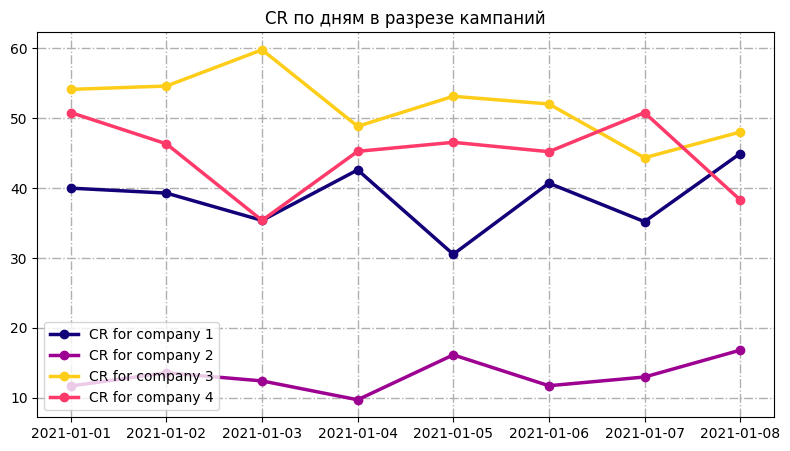

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

plt.plot(cr_1['datetime'],cr_1['CR'], label = "CR for company 1", linestyle='-', color = '#120078',linewidth=2.5,marker='o')
plt.plot(cr_2['datetime'],cr_2['CR'], label = "CR for company 2", linestyle='-', color = '#9D0191',linewidth=2.5,marker='o')
plt.plot(cr_3['datetime'],cr_3['CR'], label = "CR for company 3", linestyle='-', color = '#FECD1A',linewidth=2.5,marker='o')
plt.plot(cr_4['datetime'],cr_4['CR'], label = "CR for company 4", linestyle='-', color = '#FD3A69',linewidth=2.5,marker='o')
plt.legend(loc=3)
#plt.yticks(visit_buy_c['CR'], fontsize=11)
#ax.set_xticklabels(fontsize=10)
ax.grid(True, linewidth = "1", linestyle = "-.")
ax.set_title('CR по дням в разрезе кампаний')
plt.show()

# New задание
Однофакторный дисперсионный анализ частоты покупок
Посчитать показатели по типам объявлений
для графических кампаний оценить вклад каждой кампаний по типам. Какой вклад каждой кампании в CPC, СРО и т.д.

In [ ]:
#Конверсия CR по типам объявлений
visits=data3.groupby('company_type')['company_id'].count()
#print(visits)
#У каждой компании по 1000 наблюдений
buy=data3.groupby('company_type')['buy'].sum()
#print(buy)
#Количество целевых действий
#Конверсия в %
conversion=data3.groupby('company_type')['buy'].sum()/visits*100
#print(conversion)
#CPO - Расходы на рекламу
df1=data3.groupby('company_type')['cost'].sum()
data4 = pd.concat([df1, buy], axis=1)
data4['revenue']=data4['buy']*300
data4['profit']=data4['revenue']-data4['cost']
data4['CPO']=round(data4['cost']/data4['buy'], 2)

#ROAS -  Рентабельность затрат на рекламу
#ROAS = (Доход с рекламы / Расходы на рекламу) * 100%
data4['ROI']=round((data4['buy']*300-data4['cost'])/data4['cost']*100, 2)
data4['CPC']=round(data4['cost']/1000, 2)
data4['CR'] = conversion
data4['revenue_cli']=round(data4['revenue']/1000, 2)
#print(data4)
df5=data4[['profit','ROI','revenue_cli','CPO','CPC', 'CR' ]]
print(df5)

              profit     ROI  revenue_cli     CPO    CPC     CR
company_type                                                   
видео          78400  101.82        155.4  148.65   77.0  51.80
графическая   146900  142.62        249.9  123.65  103.0  41.65
текст          29300  293.00         39.3   76.34   10.0  13.10


In [ ]:
v_v=data3[data3['company_type']=='видео']
gr_v=data3[data3['company_type']=='графическая']
t_v=data3[data3['company_type']=='текст']
v_v.groupby('datetime')['buy'].sum()

datetime
2021-01-01    72
2021-01-02    71
2021-01-03    64
2021-01-04    64
2021-01-05    59
2021-01-06    76
2021-01-07    51
2021-01-08    61
Name: buy, dtype: int64

In [ ]:
#дисперсионный анализ частоты покупок
from scipy.stats import f_oneway
disp = f_oneway(v_v.groupby('datetime')['buy'].sum(),t_v.groupby('datetime')['buy'].sum(),gr_v.groupby('datetime')['buy'].sum())
print(disp)
#H0: нет статистически значимых различий  µ 1 = µ 2 = µ 3 = … = 0


F_onewayResult(statistic=289.1838939630207, pvalue=5.218214264620156e-16)


<ipython-input-71-2e2abfbca3e4>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Видео')


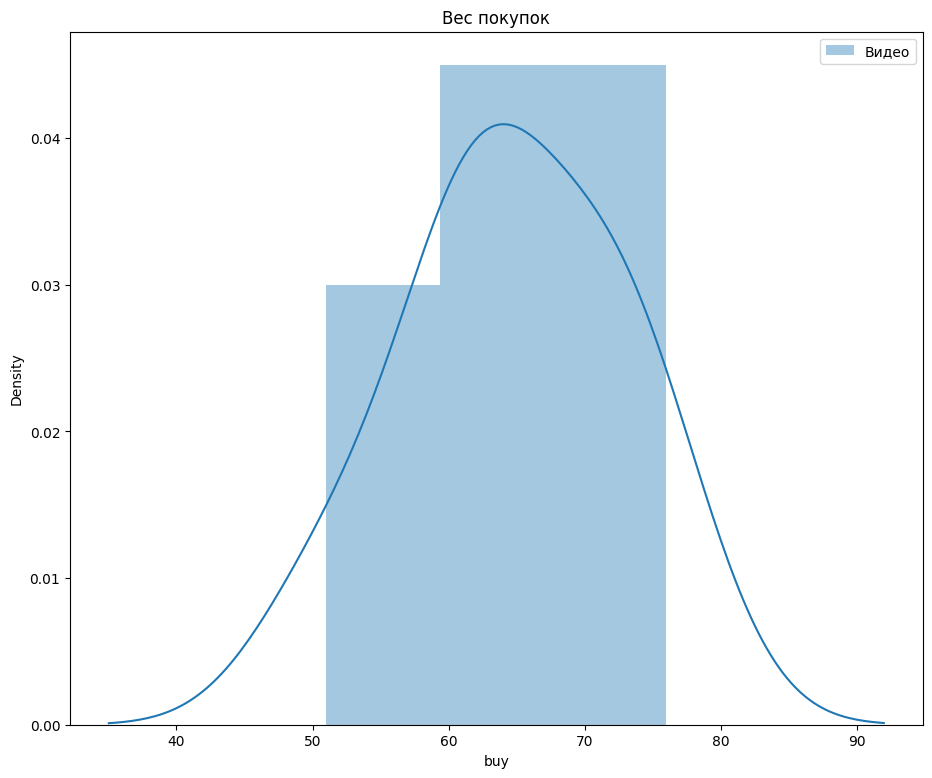

           company_id                              client_id          \
                 mean median count_nonzero  std         mean  median   
datetime                                                               
2021-01-01        3.0    3.0           133  0.0  2514.105263  2532.0   
2021-01-02        3.0    3.0           130  0.0  2510.123077  2518.0   
2021-01-03        3.0    3.0           107  0.0  2474.607477  2427.0   
2021-01-04        3.0    3.0           131  0.0  2497.977099  2514.0   
2021-01-05        3.0    3.0           111  0.0  2500.792793  2502.0   
2021-01-06        3.0    3.0           146  0.0  2516.171233  2502.0   
2021-01-07        3.0    3.0           115  0.0  2492.313043  2481.0   
2021-01-08        3.0    3.0           127  0.0  2489.960630  2505.0   

                                           buy                                 \
           count_nonzero         std      mean median count_nonzero       std   
datetime                                     

<ipython-input-71-2e2abfbca3e4>:7: FutureWarning: ['company_type'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  print(v_v.groupby('datetime').agg([np.mean, np.median, np.count_nonzero, np.std ]))


In [ ]:
f, ax = plt.subplots( figsize =(11,9) )
sns.distplot(v_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Видео')
plt.title( 'Вес покупок' )
plt.legend()
plt.show()

print(v_v.groupby('datetime').agg([np.mean, np.median, np.count_nonzero, np.std ]))

<ipython-input-63-d6ef527be763>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Видео')
<ipython-input-63-d6ef527be763>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Текст')
<ipyth

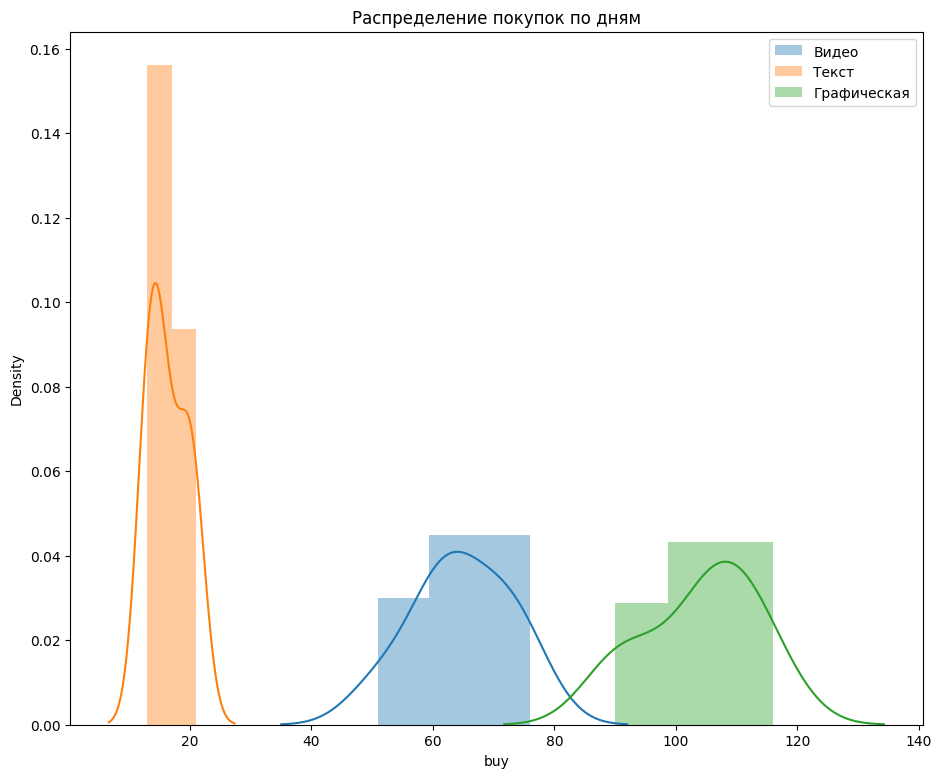

In [ ]:
import seaborn as sns

f, ax = plt.subplots( figsize =(11,9) )
sns.distplot(v_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Видео')
sns.distplot(t_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Текст')
sns.distplot(gr_v.groupby('datetime')['buy'].sum(), ax = ax, label = 'Графическая')
plt.title( 'Вес покупок' )
plt.legend()
plt.show()

